In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
work_path = "M:/1confiProj/"
os.chdir(work_path)
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from utils.help_function_old import *
from scripts.modelClassGPU_old import ConfiModel 
from scripts.modelClassGPU import ConfiModel as new_model
from scripts.experiments import ModelEvaluator


device is : cpu
device is : cpu


In [6]:
model_id = 1
#sub_id = 2
sub_lst = [2, 3, 5, 6 ,11 ,15 ,20,25]
# if 0:
    # model = ConfiModel(model_id)
    # df_sim = pd.DataFrame()
    # for sub_id in sub_lst:
    #     df_sim_sub = get_model_prediction(model, sub_id)
    #     df_sim = pd.concat([df_sim, df_sim_sub], ignore_index = True)
    #df_sim.head()
# else:
ev = ModelEvaluator('high_low_vis') 
df_sim = []
# aggreagte all the subjects
for sub_id in ev.exp.sub_lst_all:
    m_id=1
    df_sim_t = ev.get_model_prediction(m_id = m_id, sub_id = sub_id, nsim=1000)
    df_sim_t['model_id'] = m_id
    df_sim.append(df_sim_t) 

df_sim = pd.concat(df_sim, ignore_index = True)





 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 


M:\1confiProj\scripts\experiments.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
M:\1confiProj\scripts\experiments.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(remove_outliers)
M:\1confiProj\scripts\experiments.py:235: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping column

### detailed plots


In [7]:
# prepare plot data
#1. filter the data before plotting - auditory and which visual reliability - high
df_plot = df_sim.loc[df_sim.blockType == 1, :]
nPnts = 40
df_plot_filterd = df_plot.groupby(['sub_id', 'AudLoc', 'VisLoc', 'VisRel']).head(nPnts).reset_index(drop=True)

sorted_by = 'audbias'
# first sort the data according to either auditory spatial bias or CI size
if sorted_by == 'audbias':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'RespLoc'], ascending = True).reset_index(drop = True)
elif sorted_by == 'ci':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'CISize'], ascending = True).reset_index(drop = True)

df_plot_filterd['TrialNrOrdered'] = np.tile(np.arange(1, nPnts+1), df_plot_filterd.shape[0]//nPnts)

#according to David's logic, first make the confLevel from common and separate sources with different dign (but is it necessary?)
df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel'] = -1 * df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel']


In [8]:
#avergage across subjects
dfAggAud = df_plot_filterd.groupby(['AudLoc', 'VisLoc', 'VisRel', 'TrialNrOrdered'])[['RespLoc', 'CISize', 'Sources', 'ConfLevel']].mean().reset_index()
dfAggAud['ConfLevel'] = abs(dfAggAud['ConfLevel'])
dfAggAud['ConfLevel'] = round(dfAggAud['ConfLevel'])

# according to David's logic, reassign the common source judgement based on mean Sources
dfAggAud.loc[dfAggAud['Sources']-1<=0.5, 'Sources_new'] = 1
dfAggAud.loc[dfAggAud['Sources']-1>0.5, 'Sources_new'] = 2

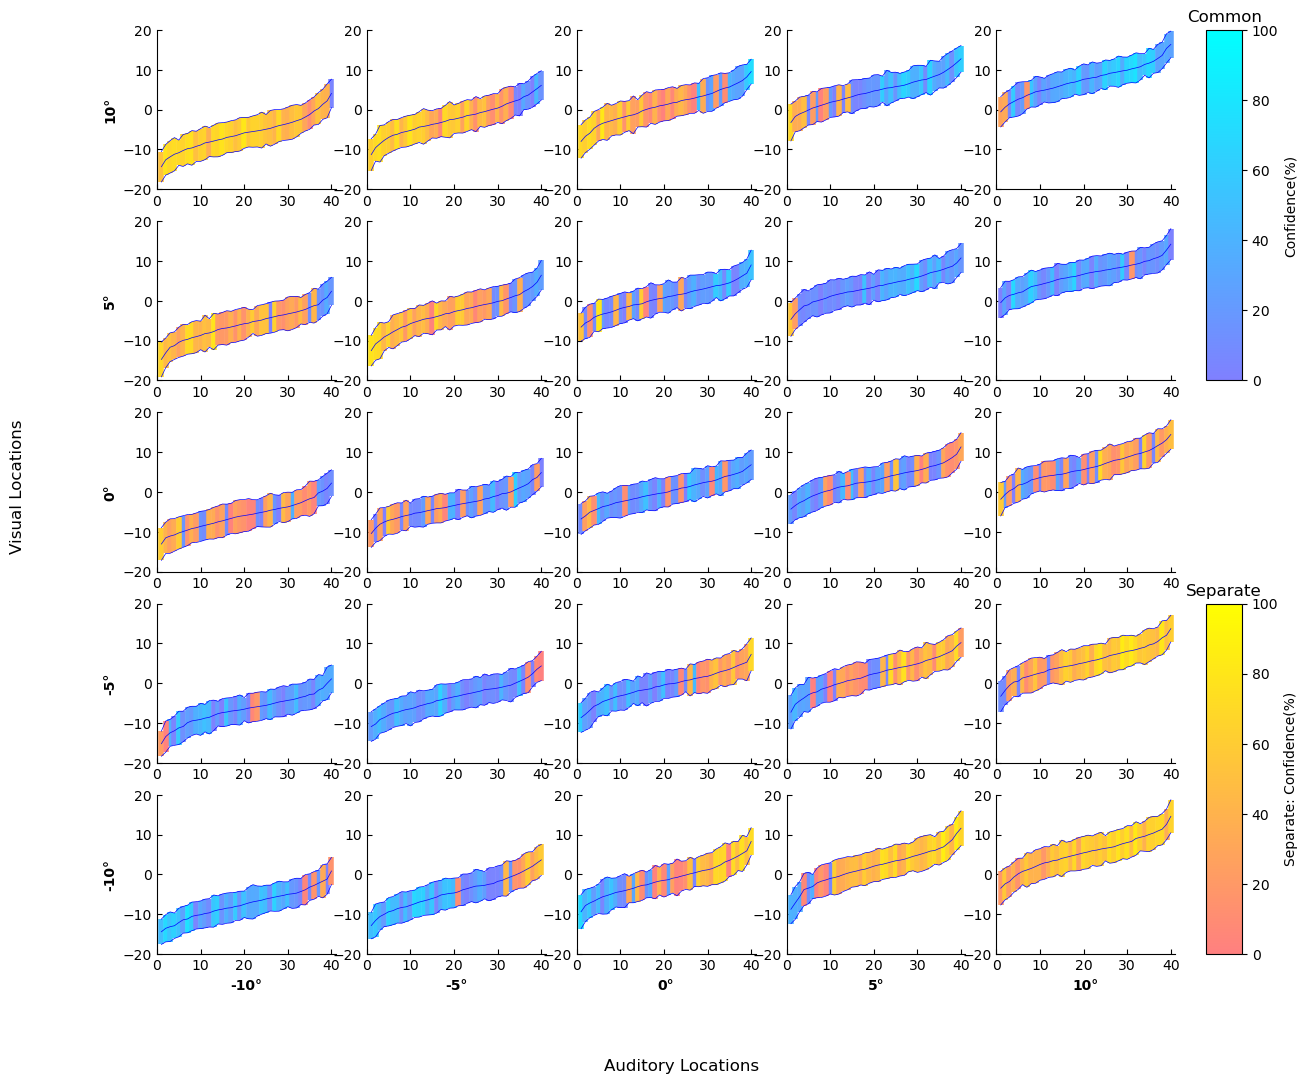

In [10]:
###################
####### Plot ######
###################
# OneSource_LowConf   = [0.50 0.50 1.00];     %halfway magenta and cyan
# OneSource_HighConf  = [0.00 1.00 1.00];     %cyan
# TwoSource_LowConf   = [1.00 0.50 0.50];     %halfway magenta and yellow
# TwoSource_HighConf  = [1.00 1.00 0.00];     %yellow
# Define two colormaps - shared
cmap_com = LinearSegmentedColormap.from_list('common', [[0.50 ,0.50 ,1.00], [0.00 ,1.00 ,1.00]])  
cmap_sep = LinearSegmentedColormap.from_list('separate', [[1.00 ,0.50 ,0.50], [1.00 ,1.00 ,0.00]])  
norm = plt.Normalize(0, 100)
# the audiovisual grid 
Alocs = [-10, -5, 0, 5, 10]
Vlocs = [10, 5, 0, -5, -10]
visrel_map = {1:"High", 2:"Low"}

rel = 2  #Visual reliability level ('1' = high reliability [2 SD], '2' = low reliability [14 SD])

#plot function
def plot1AVpair(dfAggAud, axs, i, j, smooth=0):
    
    data = dfAggAud[(dfAggAud.AudLoc== Alocs[j]) & (dfAggAud.VisLoc== Vlocs[i]) & (dfAggAud.VisRel== rel)].reset_index(drop = True)
    ax = axs[i,j]
    
    if smooth == 0:
        # Create color mappings
        com_colors = cmap_com(norm(data.loc[data.Sources_new==1, 'ConfLevel']))
        sep_colors = cmap_sep(norm(data.loc[data.Sources_new==2, 'ConfLevel']))
    else:
        # add smoothing colors
        sigma = 0.5  #larger = more smoothing
        smoothed_com_conf = gaussian_filter1d(data.loc[data.Sources_new == 1, 'ConfLevel'], sigma)
        smoothed_sep_conf = gaussian_filter1d(data.loc[data.Sources_new == 2, 'ConfLevel'], sigma)
        # Create color mappings with smoothed confidence levels
        com_colors = cmap_com(norm(smoothed_com_conf))
        sep_colors = cmap_sep(norm(smoothed_sep_conf))
    
    # Prepare CI bar 
    com_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources_new'] == 1, ['TrialNrOrdered', 'RespLoc', 'CISize']].values
    ]
    sep_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources_new'] == 2, ['TrialNrOrdered', 'RespLoc', 'CISize']].values
    ]
    
    # Create two LineCollections for different probability groups
    com_collection = LineCollection(com_segments, colors=com_colors, linewidths=4)
    sep_collection = LineCollection(sep_segments, colors=sep_colors, linewidths=4)
   
    # Add two sets of CI bars
    ax.add_collection(com_collection)
    ax.add_collection(sep_collection)
    
    # add three lines: the response location, the top and bottom CI
    ax.plot(data['TrialNrOrdered'], data['RespLoc'], color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['RespLoc']+data['CISize']/2, color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['RespLoc']-data['CISize']/2, color = 'b', lw = 0.5)

    #clean axes
    clean_axs(ax, 10)
    ax.set_xticks(np.arange(0, nPnts + 1, step=10))  
    ax.set_xlim(0, nPnts + 1)  
    ax.set_ylim(-20, 20)
    
    if i==4:
        ax.set_xlabel(f"{Alocs[j]}\u00b0", fontweight = 'bold')
        
    if j==0:
        ax.set_ylabel(f"{Vlocs[i]}\u00b0", fontweight = 'bold')


# Plot
#fig, axs = plt.subplots(figsize=(12, 12), ncols = 6, nrows = 5, sharey=True, width_ratios=[1, 1, 1, 1, 1, 0.2])
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(5, 6, width_ratios=[1, 1, 1, 1, 1, 0.2], figure=fig)

# Create subplots for data
axs = [[fig.add_subplot(gs[row, col]) for col in range(5)] for row in range(5)]
axs = np.array(axs)

for i in np.arange(5):
    for j in np.arange(5):
        plot1AVpair(dfAggAud, axs, i, j)

# # Add two colorbars
cbar_ax_com = fig.add_subplot(gs[:2, 5]) 
cbar_ax_sep = fig.add_subplot(gs[3:, 5]) 
sm_com = plt.cm.ScalarMappable(cmap=cmap_com, norm=norm)
cbar_com = plt.colorbar(sm_com, cax=cbar_ax_com)
cbar_com.set_label("Confidence(%)")
cbar_com.ax.set_title("Common")
sm_sep = plt.cm.ScalarMappable(cmap=cmap_sep, norm=norm)
cbar_sep = plt.colorbar(sm_sep, cax=cbar_ax_sep)
cbar_sep.set_label("Separate: Confidence(%)")
cbar_sep.ax.set_title("Separate")
fig.supxlabel('Auditory Locations')
fig.supylabel('Visual Locations')
#plt.title(f"Visual reliability level: {visrel_map[rel]}")
#plt.savefig(os.path.join('./output', 'beh_sortby_' + sorted_by + '_Vreli_' + str(rel) + '.png'), dpi = 300)
plt.show()

# agg plot

In [ ]:
# prepare plot data
#1. filter the data before plotting - auditory and which visual reliability - high
df_plot = df_sim.loc[df_sim.blockType == 1, :]
nPnts = 40
df_plot_filterd = df_plot.groupby(['sub_id', 'AudLoc', 'VisLoc', 'VisRel']).head(nPnts).reset_index(drop=True)

sorted_by = 'audbias'
# first sort the data according to either auditory spatial bias or CI size
if sorted_by == 'audbias':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'flipBias'], ascending = True).reset_index(drop = True)
elif sorted_by == 'ci':
    df_plot_filterd = df_plot_filterd.sort_values(by = ['sub_id', 'AudLoc', 'VisLoc', 'VisRel', 'CISize'], ascending = True).reset_index(drop = True)

df_plot_filterd['TrialNrOrdered'] = np.tile(np.arange(1, nPnts+1), df_plot_filterd.shape[0]//nPnts)

#according to David's logic, first make the confLevel from common and separate sources with different dign (but is it necessary?)
df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel'] = -1 * df_plot_filterd.loc[df_plot_filterd.Sources==1, 'ConfLevel']


In [11]:

#avergage across subjects
dfAggAud = df_plot_filterd.groupby(['abs_delta_VA', 'VisRel', 'TrialNrOrdered'])[['flipBias', 'CISize', 'Sources', 'ConfLevel']].mean().reset_index()
dfAggAud['ConfLevel'] = abs(dfAggAud['ConfLevel'])
dfAggAud['ConfLevel'] = round(dfAggAud['ConfLevel'])

# according to David's logic, reassign the common source judgement based on mean Sources
dfAggAud.loc[dfAggAud['Sources']-1<=0.5, 'Sources_new'] = 1
dfAggAud.loc[dfAggAud['Sources']-1>0.5, 'Sources_new'] = 2

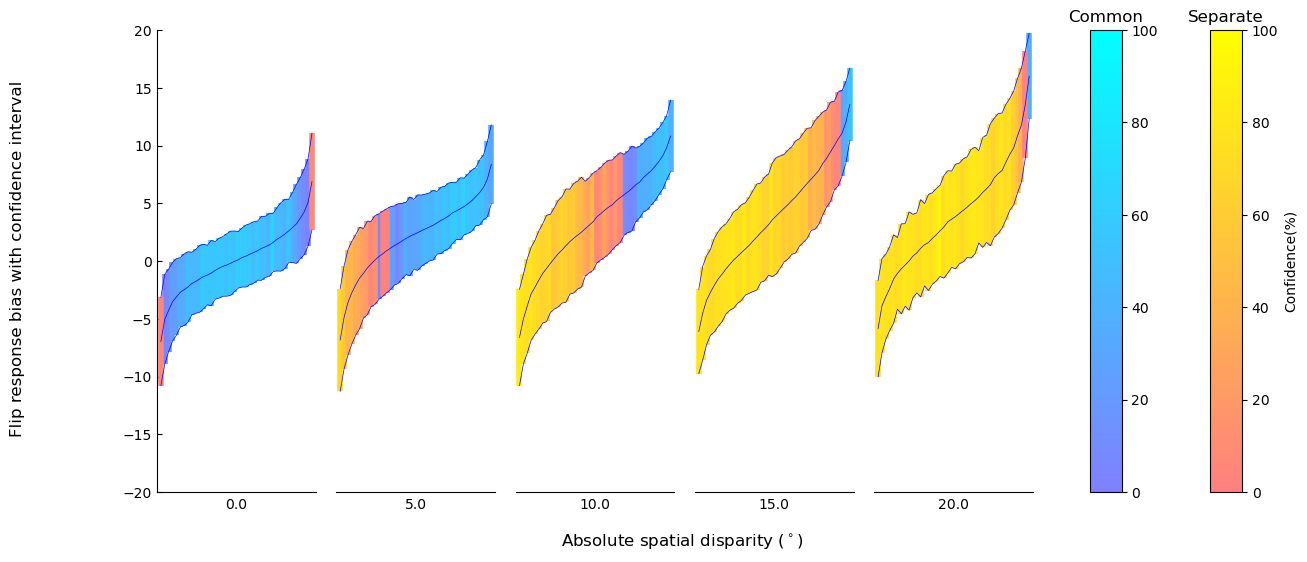

In [12]:


###################
####### Plot ######
###################
# Define two colormaps - shared
cmap_com = LinearSegmentedColormap.from_list('common', [[0.50 ,0.50 ,1.00], [0.00 ,1.00 ,1.00]])  
cmap_sep = LinearSegmentedColormap.from_list('separate', [[1.00 ,0.50 ,0.50], [1.00 ,1.00 ,0.00]])  
norm = plt.Normalize(0, 100)
# the audiovisual grid 
del_lst = dfAggAud.abs_delta_VA.unique()
Alocs = [-10, -5, 0, 5, 10]
Vlocs = [10, 5, 0, -5, -10]
visrel_map = {1:"High", 2:"Low"}

rel = 1  #Visual reliability level ('1' = high reliability [2 SD], '2' = low reliability [14 SD])

#plot function
def plot1AVpair(dfAggAud, axs, i, smooth=0):
    
    data = dfAggAud[(dfAggAud.abs_delta_VA== del_lst[i]) & (dfAggAud.VisRel== rel)].reset_index(drop = True)
    ax = axs[i]
    
    if smooth == 0:
        # Create color mappings
        com_colors = cmap_com(norm(data.loc[data.Sources_new==1, 'ConfLevel']))
        sep_colors = cmap_sep(norm(data.loc[data.Sources_new==2, 'ConfLevel']))
    else:
        # add smoothing colors
        sigma = 0.5  #larger = more smoothing
        smoothed_com_conf = gaussian_filter1d(data.loc[data.Sources_new == 1, 'ConfLevel'], sigma)
        smoothed_sep_conf = gaussian_filter1d(data.loc[data.Sources_new == 2, 'ConfLevel'], sigma)
        # Create color mappings with smoothed confidence levels
        com_colors = cmap_com(norm(smoothed_com_conf))
        sep_colors = cmap_sep(norm(smoothed_sep_conf))
    
    # Prepare CI bar 
    com_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources_new'] == 1, ['TrialNrOrdered', 'flipBias', 'CISize']].values
    ]
    sep_segments = [
        [[x, y - err / 2], [x, y + err / 2]]  # Bottom to top segment
        for x, y, err in data.loc[data['Sources_new'] == 2, ['TrialNrOrdered', 'flipBias', 'CISize']].values
    ]
    
    # Create two LineCollections for different probability groups
    com_collection = LineCollection(com_segments, colors=com_colors, linewidths=4)
    sep_collection = LineCollection(sep_segments, colors=sep_colors, linewidths=4)
   
    # Add two sets of CI bars
    ax.add_collection(com_collection)
    ax.add_collection(sep_collection)
    
    # add three lines: the response location, the top and bottom CI
    ax.plot(data['TrialNrOrdered'], data['flipBias'], color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['flipBias']+data['CISize']/2, color = 'b', lw = 0.5)
    ax.plot(data['TrialNrOrdered'], data['flipBias']-data['CISize']/2, color = 'b', lw = 0.5)

    #clean axes
    clean_axs(ax, 10)
    ax.set_xticks(np.arange(0, nPnts + 1, step=10))  
    ax.set_xlim(0, nPnts + 1)  
    ax.set_ylim(-20, 20)
    


# Plot
#fig, axs = plt.subplots(figsize=(12, 12), ncols = 6, nrows = 5, sharey=True, width_ratios=[1, 1, 1, 1, 1, 0.2])
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, len(del_lst)+4, width_ratios=[1, 1, 1, 1, 1, 0.1, 0.2, 0.3, 0.2], figure=fig)

# Create subplots for data
axs = [fig.add_subplot(gs[col]) for col in range(len(del_lst))] 
axs = np.array(axs)

for i in np.arange(len(del_lst)):
    plot1AVpair(dfAggAud, axs, i)
    axs[i].set_xticks([])
    axs[i].set_xlabel(del_lst[i])

# # Add two colorbars
cbar_ax_com = fig.add_subplot(gs[len(del_lst)+1]) 
cbar_ax_sep = fig.add_subplot(gs[len(del_lst)+3]) 
sm_com = plt.cm.ScalarMappable(cmap=cmap_com, norm=norm)
cbar_com = plt.colorbar(sm_com, cax=cbar_ax_com)
#cbar_com.set_label("Confidence(%)")
cbar_com.ax.set_title("Common")
sm_sep = plt.cm.ScalarMappable(cmap=cmap_sep, norm=norm)
cbar_sep = plt.colorbar(sm_sep, cax=cbar_ax_sep)
cbar_sep.set_label("Confidence(%)")
cbar_sep.ax.set_title("Separate")
fig.supxlabel('Absolute spatial disparity ($^\circ$)')
fig.supylabel('Flip response bias with confidence interval')
for i in np.arange(1, len(del_lst)):
    axs[i].set_yticks([])
    axs[i].spines['left'].set_visible(False)
    
#plt.title(f"Visual reliability level: {visrel_map[rel]}")
plt.savefig(os.path.join('./plots', 'model_prediction_sortby_' + sorted_by + '_Vreli_' + str(rel) + '.png'), dpi = 300)
plt.show()
